In [1]:
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
from matplotlib.patches import Patch as LegendPatch
import numpy as np

sys.path.append("..")
import roi_tools

classification_colors = {
    "Singlet": "#FDE725",
    "Doublet": "#440154",
}


def plot_intensity_histograms(ax, groups, bins):
    for label, values, color in groups:
        mean = np.mean(values)
        std = np.std(values)
        ax.hist(
            values, bins=bins, color=color, alpha=0.6,
            label=f"{label}",
        )
        ax.axvspan(mean - std, mean + std, color=color, alpha=0.15)
        ax.axvline(mean, color=color, linestyle="--", linewidth=1.5)
    ax.tick_params(direction="in", length=6)
    ax.legend(frameon=False)

### Exp Singlet vs Doublet mapping

In [2]:
experimental_source = hs.load("../data/images/HAADF/HAADF_Buena.dm3")
experimental_signal = experimental_source.isig[20:2028, 200:1948]
grid_creator = roi_tools.GridCreator()
experimental_layout = grid_creator.detect_layout(experimental_signal)
experimental_grid = grid_creator.process(
    experimental_signal, layout=experimental_layout
)

(
    lu_singlet_distance_map,
    lu_doublet_distance_map,
    lu_class_map,
) = roi_tools.PositionAnalyzer().get_Lu_phases(experimental_grid)

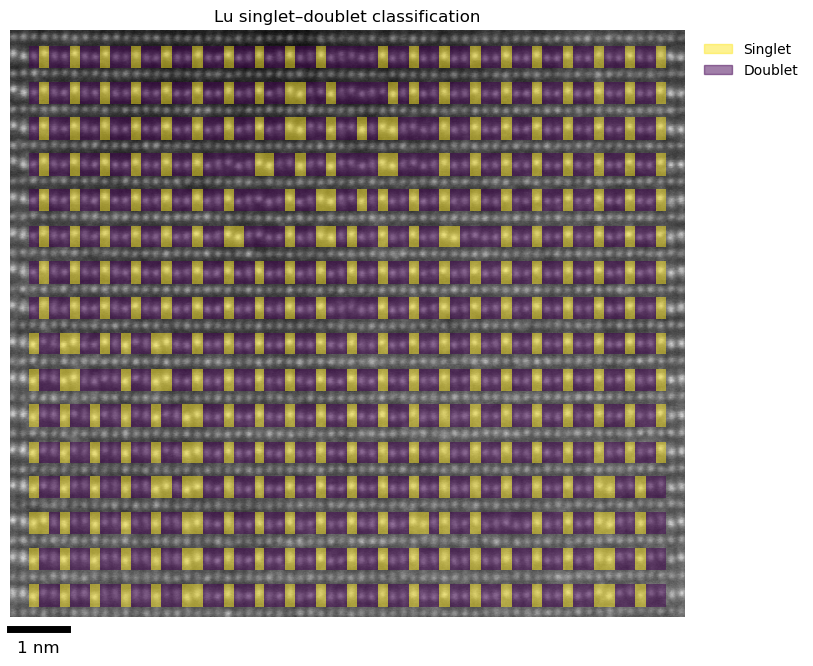

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Lu singlet–doublet classification'}>)

In [3]:
fig, ax = plt.subplots(figsize=(10, 10))
classification_plotter = roi_tools.PatchGridPlotter(
    experimental_signal, experimental_grid, ax=ax
)
for class_value, label in ((-1, "Doublet"), (1, "Singlet")):
    classification_plotter.add_boolean_faces(
        lu_class_map == class_value,
        color=classification_colors[label],
        alpha=0.5,
    )

ax.legend(
    handles=[
        LegendPatch(color=color, alpha=0.5, label=label)
        for label, color in classification_colors.items()
    ],
    frameon=False,
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
)
ax.set_title("Lu singlet–doublet classification")
fig.subplots_adjust(right=0.8)
classification_plotter.show(
    axis_on=False, scale_nm=1, scale_linewidth=5, scale_fontsize=12
)

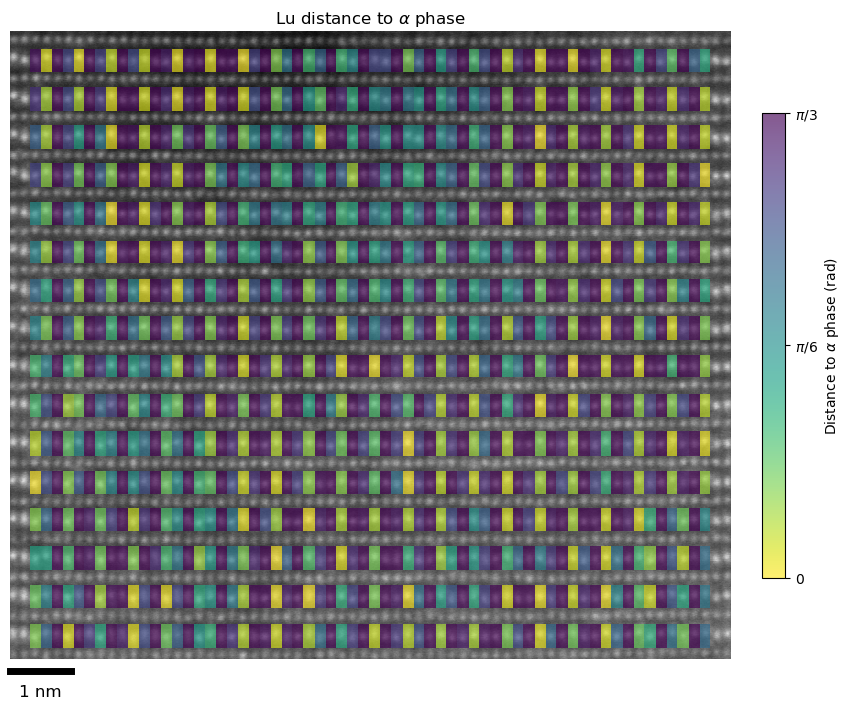

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'Lu distance to $\\alpha$ phase'}>)

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))

singlet_distance_plotter = roi_tools.PatchGridPlotter(
    experimental_signal,
    experimental_grid,
    ax=ax,
)

distance_artist = singlet_distance_plotter.add_patch_faces(
    atom_type="Lu",
    values=lu_singlet_distance_map,
    cmap="viridis_r",
    vmin=0,
    vmax=np.pi / 3,
    alpha=0.65,
)

colorbar = singlet_distance_plotter.add_colorbar(
    distance_artist,
    fraction=0.03,
    label=r"Distance to $\alpha$ phase (rad)",
)

colorbar.set_ticks([0, np.pi / 6, np.pi / 3])
colorbar.set_ticklabels(["0", r"$\pi/6$", r"$\pi/3$"])

ax.set_title(r"Lu distance to $\alpha$ phase")

singlet_distance_plotter.show(
    axis_on=False,
    scale_nm=1,
    scale_linewidth=5,
    scale_fontsize=12,
)

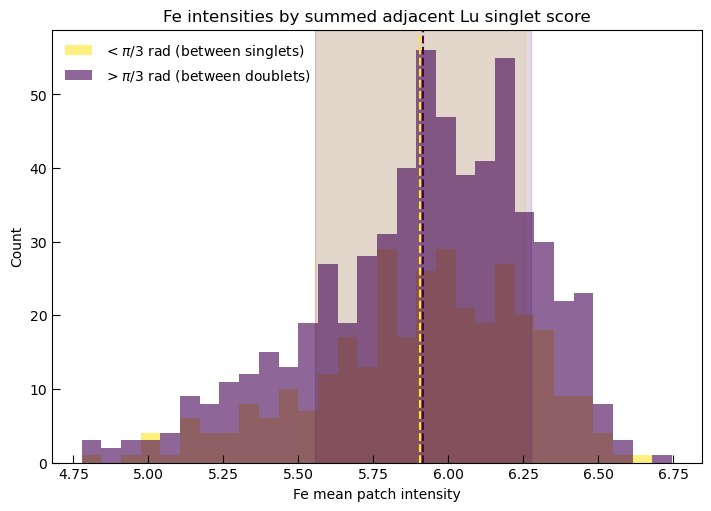

In [5]:
fe_mean_intensities = experimental_grid.values(metric="mean_intensity")
fe_mask = experimental_grid.atom_type_mask("Fe")
lu_pair_singlet_distances = np.full(experimental_grid.shape, np.nan)
lu_pair_singlet_distances[:, 1:-1] = (
    lu_singlet_distance_map[:, :-2]
    + lu_singlet_distance_map[:, 2:]
)

threshold = np.pi / 3
below_threshold = fe_mean_intensities[
    fe_mask & (lu_pair_singlet_distances < threshold)
]
above_threshold = fe_mean_intensities[
    fe_mask & (lu_pair_singlet_distances > threshold)
]
bins = np.histogram_bin_edges(
    np.concatenate((below_threshold, above_threshold)), bins=30
)

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
plot_intensity_histograms(
    ax,
    (
        (r"$< \pi/3$ rad (between singlets)", below_threshold,
         classification_colors["Singlet"]),
        (r"$> \pi/3$ rad (between doublets)", above_threshold,
         classification_colors["Doublet"]),
    ),
    bins,
)
ax.set_xlabel("Fe mean patch intensity")
ax.set_ylabel("Count")
ax.set_title("Fe intensities by summed adjacent Lu singlet score")
plt.show()

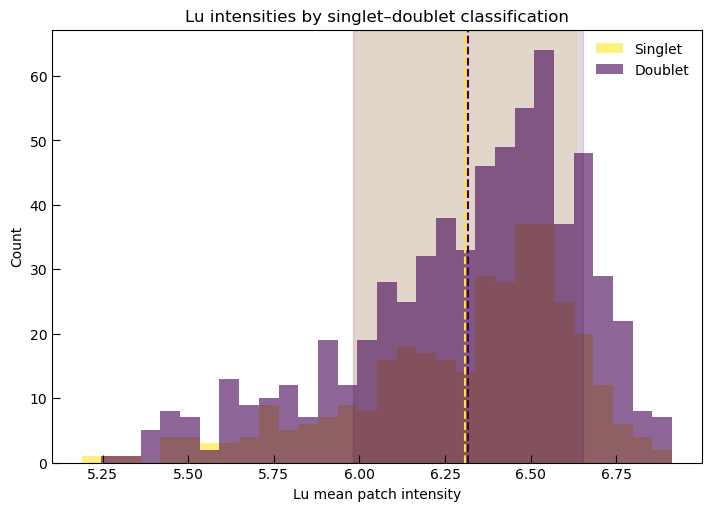

In [6]:
lu_mean_intensities = experimental_grid.values(metric="mean_intensity")
singlet_lu_intensities = lu_mean_intensities[lu_class_map == 1]
doublet_lu_intensities = lu_mean_intensities[lu_class_map == -1]
bins = np.histogram_bin_edges(
    np.concatenate((singlet_lu_intensities, doublet_lu_intensities)),
    bins=30,
)

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
plot_intensity_histograms(
    ax,
    (
        ("Singlet", singlet_lu_intensities,
         classification_colors["Singlet"]),
        ("Doublet", doublet_lu_intensities,
         classification_colors["Doublet"]),
    ),
    bins,
)
ax.set_xlabel("Lu mean patch intensity")
ax.set_ylabel("Count")
ax.set_title("Lu intensities by singlet–doublet classification")
plt.show()

### Sim Singlet vs Doublet mapping

Building ensembles:   0%|          | 0/30 [00:00<?, ?it/s]

Analyzing ensembles:   0%|          | 0/30 [00:00<?, ?it/s]

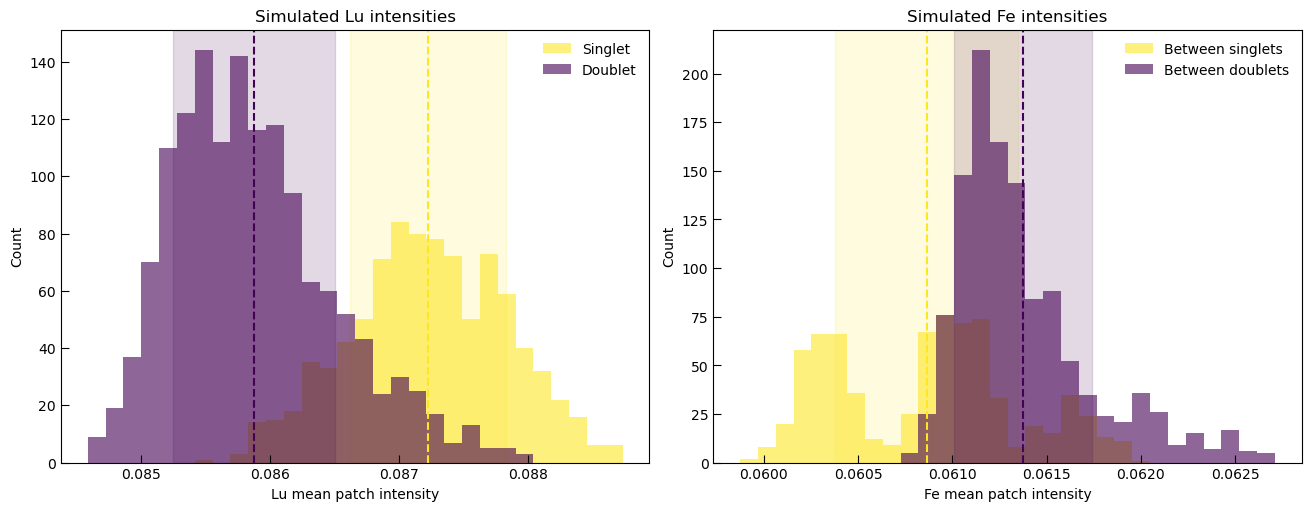

In [7]:
from pathlib import Path

from tqdm.auto import tqdm

simulation_rng = np.random.default_rng(0)
n_fp = 50
n_simulation_images = 30
simulation_files = sorted(
    Path("../data/simulations/pristine_fp").glob("pristine_fp_*.npy"),
    key=lambda path: int(path.stem.rsplit("_", 1)[1]),
)
simulation_index_sets = [
    simulation_rng.choice(len(simulation_files), n_fp, replace=False)
    for _ in range(n_simulation_images)
]
simulation_images = [
    np.stack([np.load(simulation_files[index]).squeeze() for index in indices])
    .mean(axis=0)
    for indices in tqdm(simulation_index_sets, desc="Building ensembles")
]

simulation_layout = grid_creator.detect_layout(
    hs.signals.Signal2D(simulation_images[0])
)
sim_singlet_lu_intensities = []
sim_doublet_lu_intensities = []
sim_fe_between_singlets = []
sim_other_fe_intensities = []

for image in tqdm(simulation_images, desc="Analyzing ensembles"):
    simulation_grid = grid_creator.process(
        hs.signals.Signal2D(image), layout=simulation_layout
    )
    mean_intensities = simulation_grid.values(metric="mean_intensity")
    singlet_columns = (
        np.arange(simulation_grid.shape[0])[:, None] % 3 == 0
    )
    lu_mask = simulation_grid.atom_type_mask("Lu")
    fe_mask = simulation_grid.atom_type_mask("Fe")

    sim_singlet_lu_intensities.append(
        mean_intensities[lu_mask & singlet_columns]
    )
    sim_doublet_lu_intensities.append(
        mean_intensities[lu_mask & ~singlet_columns]
    )
    sim_fe_between_singlets.append(
        mean_intensities[fe_mask & singlet_columns]
    )
    sim_other_fe_intensities.append(
        mean_intensities[fe_mask & ~singlet_columns]
    )

sim_singlet_lu_intensities = np.concatenate(sim_singlet_lu_intensities)
sim_doublet_lu_intensities = np.concatenate(sim_doublet_lu_intensities)
sim_fe_between_singlets = np.concatenate(sim_fe_between_singlets)
sim_other_fe_intensities = np.concatenate(sim_other_fe_intensities)
lu_bins = np.histogram_bin_edges(
    np.concatenate((sim_singlet_lu_intensities, sim_doublet_lu_intensities)),
    bins=30,
)
fe_bins = np.histogram_bin_edges(
    np.concatenate((sim_fe_between_singlets, sim_other_fe_intensities)),
    bins=30,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
plot_intensity_histograms(
    axes[0],
    (
        ("Singlet", sim_singlet_lu_intensities,
         classification_colors["Singlet"]),
        ("Doublet", sim_doublet_lu_intensities,
         classification_colors["Doublet"]),
    ),
    lu_bins,
)
axes[0].set_xlabel("Lu mean patch intensity")
axes[0].set_ylabel("Count")
axes[0].set_title("Simulated Lu intensities")

plot_intensity_histograms(
    axes[1],
    (
        ("Between singlets", sim_fe_between_singlets,
         classification_colors["Singlet"]),
        ("Between doublets", sim_other_fe_intensities,
         classification_colors["Doublet"]),
    ),
    fe_bins,
)
axes[1].set_xlabel("Fe mean patch intensity")
axes[1].set_ylabel("Count")
axes[1].set_title("Simulated Fe intensities")
plt.show()